# Problem Statement

**Our objective is to build a shot prediction model, whether the player will score or not score, based on the circumstances under which they are made into consideration. It will help all stakeholders develop more effective game strategies. The  goal is to find the best model that has the highest accuracy and F1-score.**

In [1]:
# Importing all the necessary libararies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset
data = pd.read_csv("E:\PRCP-1008-NBAShotSelection\data.csv")

# Basic Checks

In [7]:
data.head()

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
0,Jump Shot,Jump Shot,10,20000012,33.9723,167,72,-118.1028,10,1,...,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,1
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,5


In [9]:
data.columns

Index(['action_type', 'combined_shot_type', 'game_event_id', 'game_id', 'lat',
       'loc_x', 'loc_y', 'lon', 'minutes_remaining', 'period', 'playoffs',
       'season', 'seconds_remaining', 'shot_distance', 'shot_made_flag',
       'shot_type', 'shot_zone_area', 'shot_zone_basic', 'shot_zone_range',
       'team_id', 'team_name', 'game_date', 'matchup', 'opponent', 'shot_id'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   game_event_id       30697 non-null  int64  
 3   game_id             30697 non-null  int64  
 4   lat                 30697 non-null  float64
 5   loc_x               30697 non-null  int64  
 6   loc_y               30697 non-null  int64  
 7   lon                 30697 non-null  float64
 8   minutes_remaining   30697 non-null  int64  
 9   period              30697 non-null  int64  
 10  playoffs            30697 non-null  int64  
 11  season              30697 non-null  object 
 12  seconds_remaining   30697 non-null  int64  
 13  shot_distance       30697 non-null  int64  
 14  shot_made_flag      25697 non-null  float64
 15  shot_type           30697 non-null  object 
 16  shot

In [6]:
data.describe()

,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,playoffs,seconds_remaining,shot_distance,shot_made_flag,team_id,shot_id
count,30697.000000,3.069700e+04,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,25697.000000,3.069700e+04,30697.000000
mean,249.190800,2.476407e+07,33.953192,7.110499,91.107535,-118.262690,4.885624,2.519432,0.146562,28.365085,13.437437,0.446161,1.610613e+09,15349.000000
std,150.003712,7.755175e+06,0.087791,110.124578,87.791361,0.110125,3.449897,1.153665,0.353674,17.478949,9.374189,0.497103,0.000000e+00,8861.604943
min,2.000000,2.000001e+07,33.253300,-250.000000,-44.000000,-118.519800,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.610613e+09,1.000000
25%,110.000000,2.050008e+07,33.884300,-68.000000,4.000000,-118.337800,2.000000,1.000000,0.000000,13.000000,5.000000,0.000000,1.610613e+09,7675.000000
50%,253.000000,2.090035e+07,33.970300,0.000000,74.000000,-118.269800,5.000000,3.000000,0.000000,28.000000,15.000000,0.000000,1.610613e+09,15349.000000
75%,368.000000,2.960047e+07,34.040300,95.000000,160.000000,-118.174800,8.000000,3.000000,0.000000,43.000000,21.000000,1.000000,1.610613e+09,23023.000000
max,659.000000,4.990009e+07,34.088300,248.000000,791.000000,-118.021800,11.000000,7.000000,1.000000,59.000000,79.000000,1.000000,1.610613e+09,30697.000000


In [7]:
# Checking if there is any null value in the data
data.isnull().sum()

action_type              0
combined_shot_type       0
game_event_id            0
game_id                  0
lat                      0
loc_x                    0
loc_y                    0
lon                      0
minutes_remaining        0
period                   0
playoffs                 0
season                   0
seconds_remaining        0
shot_distance            0
shot_made_flag        5000
shot_type                0
shot_zone_area           0
shot_zone_basic          0
shot_zone_range          0
team_id                  0
team_name                0
game_date                0
matchup                  0
opponent                 0
shot_id                  0
dtype: int64

In [31]:
# Checking if there is any duplicates values in the data
data.duplicated().sum()

0

# Domain Analysis
---

##  Target Variable (The Output)
| Column Name | Description | Domain Relevance | ML Action |
| :--- | :--- | :--- | :--- |
| **`shot_made_flag`** | Binary Indicator (1 = Made, 0 = Missed). | The ultimate measure of success in basketball. | **Target Variable.** This is what we are training the model to predict. |

---

## Spatial Features (Location on Court)
*These features define the "Where." In basketball, location is the primary driver of shooting percentage.*

| Column Name | Description | Domain Relevance | ML Action |
| :--- | :--- | :--- | :--- |
| **`loc_x` / `loc_y`** | Coordinates of the shot relative to the hoop (0,0). | **Critical.** The specific spot on the floor determines the angle and difficulty. `loc_y` correlates with distance, `loc_x` with angle. | **Keep.** These are our primary features. Will use it for visualization and tree-based models. |
| **`lat` / `lon`** | Latitude and Longitude mapping of the court. | Redundant. In this dataset, these are just linear transformations of `loc_x` and `loc_y`. | **Drop.** They add no new information and introduce high multicollinearity (redundancy). |
| **`shot_distance`** | Distance from the hoop in feet. | **High Impact.** Physics dictates that accuracy decreases as distance increases. | **Keep.** Strongest numerical predictor. |
| **`shot_zone_area`** | Broad area (e.g., "Left Side", "Center"). | Human-readable grouping of locations. Helps analyze "Left vs Right" bias. | **Keep (Categorical).** Good for analysis, but one-hot encode for the model. |
| **`shot_zone_basic`** | Basic zone (e.g., "Restricted Area", "Mid-Range"). | Defines the type of defense the player likely faced (e.g., Restricted Area = Heavy Contact). | **Keep.** Useful for grouping shot types. |
| **`shot_zone_range`** | Range bins (e.g., "16-24 ft"). | Categorical version of `shot_distance`. | **Drop**this might be redundant for the model, but great for EDA. |

---

## Behavioral Features (Shot Mechanics)
*These features define the "How." Kobe was known for difficult shot making.*

| Column Name | Description | Domain Relevance | ML Action |
| :--- | :--- | :--- | :--- |
| **`action_type`** | Specific move (e.g., "Turnaround Jump Shot", "Dunk"). | **Critical.** A "Dunk" has 95% accuracy; a "Fadeaway" has 40%. This captures the difficulty of the shot better than location alone. | **Keep & Clean.** High cardinality (many unique values). Group rare actions into "Other" to avoid overfitting. |
| **`combined_shot_type`** | General move (e.g., "Jump Shot", "Layup"). | A broader grouping of `action_type`. | **Drop/keep.** It is less informative than `action_type`. |
| **`shot_type`** | "2PT Field Goal" or "3PT Field Goal". | Defines the point value. | **Redundant.** This information is already captured by `shot_distance` (Distance > 23ft is a 3PT). |

---

## Temporal Features (Time & Situation)
*These features define the "When." Basketball involves fatigue and pressure.*

| Column Name | Description | Domain Relevance | ML Action |
| :--- | :--- | :--- | :--- |
| **`period`** | Quarter of the game (1-4, plus Overtime). | Fatigue and pressure increase as the period increases. | **Keep.** Could be Categorical or Ordinal. |
| **`minutes_remaining`** | Minutes left in the quarter. | Used to calculate total time. | **Transform.** Plan to combine with `seconds` to create a single `time_remaining` feature. |
| **`seconds_remaining`** | Seconds left in the current minute. | Granular time data. | **Transform.** Combine with `minutes`. |
| **`season`** | The year (e.g., "1996-97"). | Captures the player's age and physical prime. Kobe's stats in 2016 were worse than 2006. | **Keep.** Extract the start year (e.g., 1996) to make it numerical/ordinal. |
| **`playoffs`** | Binary (0 = Regular Season, 1 = Playoffs). | Playoff games feature tougher defense and higher pressure. | **Keep.** Useful context variable. |
| **`game_date`** | Date of the match. | Could track "Rest Days" (Fatigue), but complex to engineer. | **Drop.** but it can be useful to engineer "Days since last game." |

---

##  Contextual Features (Opponent & Matchup)
*These features define the "Who."*

| Column Name | Description | Domain Relevance | ML Action |
| :--- | :--- | :--- | :--- |
| **`matchup`** | String (e.g., "LAL vs PHX"). | Contains two hidden pieces of info: Opponent Name and Home/Away status. | **Feature Engineer.** Extract `is_home_game` (vs.) and drop the raw string. |
| **`opponent`** | The opposing team abbreviation. | Some teams have better defenses than others. | **Keep.** One-hot encode. |
| **`team_id` / `team_name`** | "LAL" / "Los Angeles Lakers". | Constant value. Kobe only played for the Lakers. | **Drop.** Constant columns have zero variance and zero predictive power. |

---

##  Identifiers 
*These are for database management, not prediction.*

| Column Name | Description | Domain Relevance | ML Action |
| :--- | :--- | :--- | :--- |
| **`shot_id`** | Unique row identifier. | Just an index. | **Drop.** Will cause overfitting if included (Model will memorize IDs). |
| **`game_id`** | Unique match identifier. | Groups shots belonging to the same game. | **Drop.** not useful. |
| **`game_event_id`** | Sequential order of events in game. | Tells us if the shot was early or late in the game flow. | **keep.** `minutes_remaining` covers the time aspect better. |

---

*"By analyzing the domain, we identified that **Spatial features** (Location) and **Behavioral features** (Action Type) are likely the strongest predictors. We also identified several **redundant features** (lat/lon, team_id) that must be removed during preprocessing to prevent multicollinearity and noise."*

# Exploratory Data Analysis(EDA)

In [22]:
# Removing the null values to get an accurate visuals
df_eda = data.dropna(subset=['shot_made_flag']).copy()

In [71]:
# Binning Shot Distances for clearer analysis
# We cut distance into categories: <8ft, 8-16ft, 16-24ft, 24+ft
bins = [-1, 8, 16, 24, 100]
labels = ['Under Basket (<8ft)', 'Mid-Range (8-16ft)', 'Long-Mid (16-24ft)', '3-Point (24ft+)']
df_eda['shot_distance_bin'] = pd.cut(df_eda['shot_distance'], bins=bins, labels=labels)

In [73]:
# Drawing an NBA basketball court on a matplotlib axes.

def draw_court(ax=None, color='black', lw=2, outer_lines=False):
    if ax is None:
        ax = plt.gca()

    # Create the various parts of an NBA basketball court

    # Create the basketball hoop
    # Diameter of a hoop is 18" so it has a radius of 9", which is a value
    # 7.5 in our coordinate system
    hoop = patches.Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Create backboard
    backboard = patches.Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # The paint
    # Create the outer box 0f the paint, width=16ft, height=19ft
    outer_box = patches.Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    # Create the inner box of the paint, widt=12ft, height=19ft
    inner_box = patches.Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)

    # Create free throw top arc
    top_free_throw = patches.Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)
    # Create free throw bottom arc
    bottom_free_throw = patches.Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    # Restricted Zone, it is an arc with 4ft radius from center of the hoop
    restricted = patches.Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)

    # Three point line
    # Create the side 3pt lines, they are 14ft long before they begin to arc
    corner_three_a = patches.Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = patches.Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    # 3pt arc - center of arc will be the hoop, arc is 23'9" away from hoop
    three_arc = patches.Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)

    # Center Court
    center_outer_arc = patches.Arc((0, 422.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color)
    center_inner_arc = patches.Arc((0, 422.5), 40, 40, theta1=180, theta2=0, linewidth=lw, color=color)

    # List of the court elements to be plotted onto the axes
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc,
                      center_inner_arc]

    if outer_lines:
        # Draw the half court line, baseline and side lines
        outer_lines = patches.Rectangle((-250, -47.5), 500, 470, linewidth=lw,
                                        color=color, fill=False)
        court_elements.append(outer_lines)

    # Add the court elements to the axes
    for element in court_elements:
        ax.add_patch(element)

    return ax

# Univariant Analysis

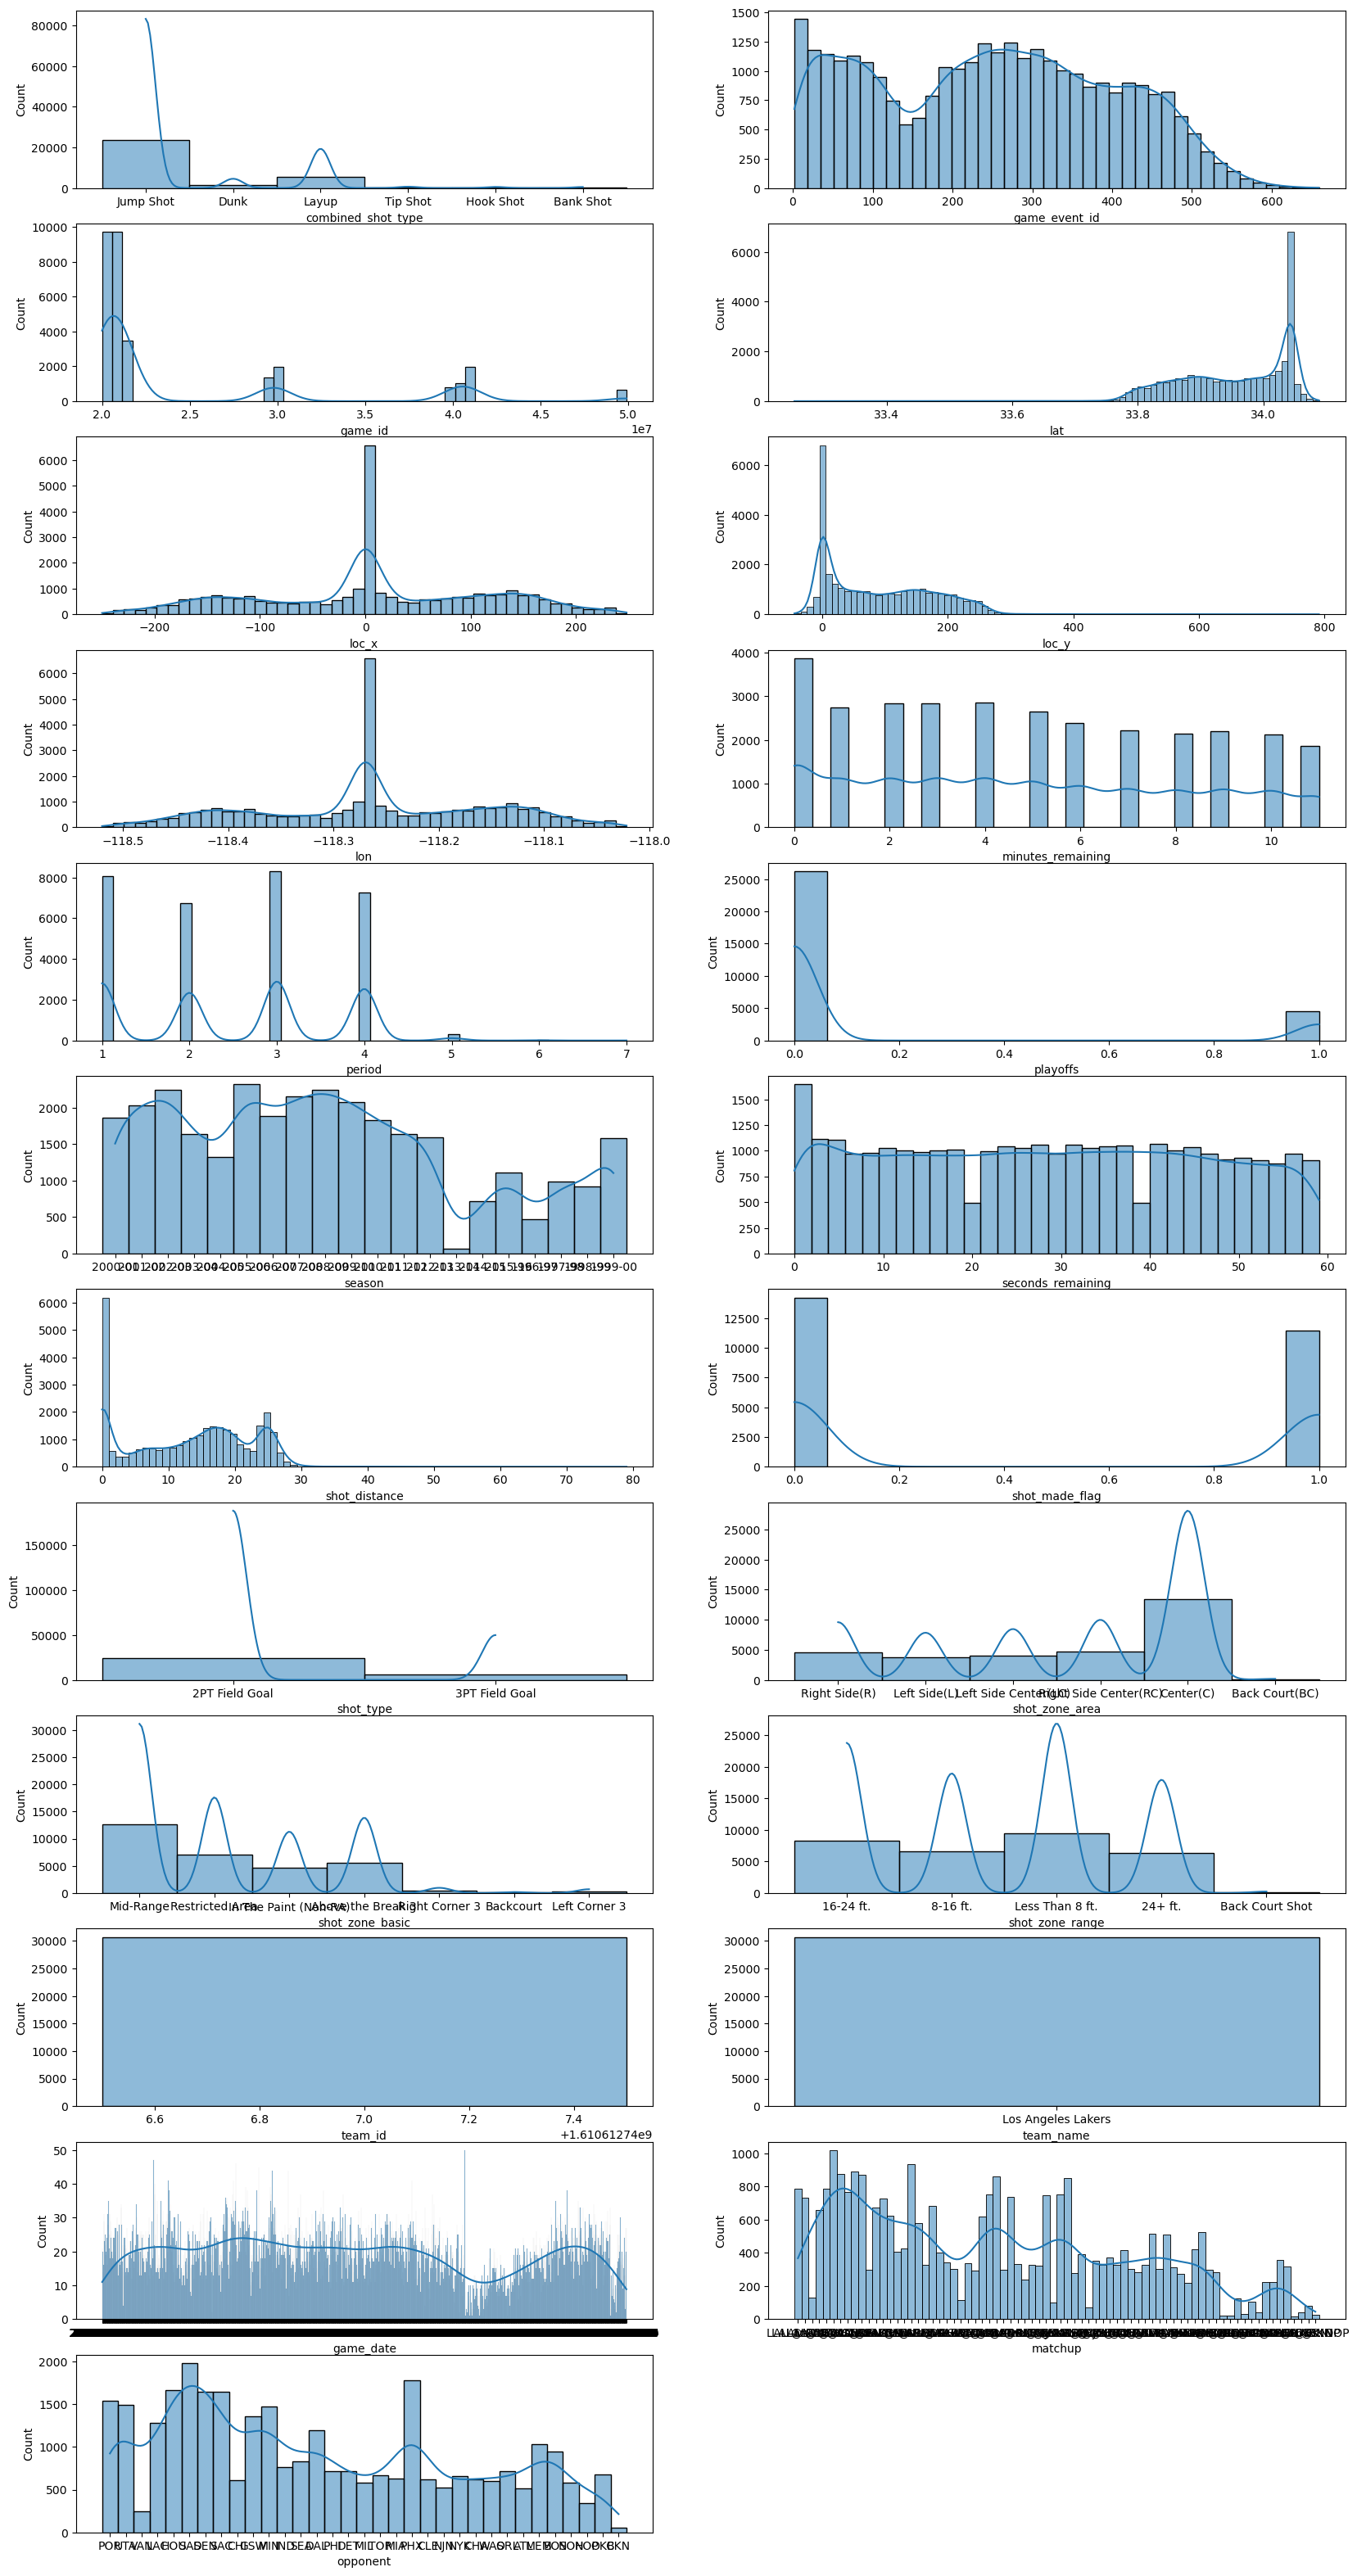

In [19]:
# Plotting histplot of each columns of dataset
figure=plt.figure(figsize=(20,40))
for i in range(1,24):
    plt.subplot(12,2,i)
    sns.histplot(data.iloc[:,i],kde=True)

### Target Distribution: `shot_made_flag`
**Objective:** To determine the baseline accuracy and check for class imbalance.

**Observation:**
*   The dataset shows that Kobe Bryant misses approximately **55%** of his shots and makes **45%**.
*   **Insight:** The classes are relatively balanced (45/55 split), which means we **do not** need to apply aggressive resampling techniques like SMOTE.

### Numerical Distribution: `shot_distance`
**Objective:** To analyze Kobe's shooting range tendencies.

**Observation:**
*   **Bimodal Distribution:** The histogram shows two distinct peaks:
    1.  **Short Range (0-5 ft):** Represents layups and dunks under the basket.
    2.  **Long Range (23-25 ft):** Represents the 3-point line.
*   **The "Dead Zone":** There is a dip in frequency between 10-18 feet (Long 2s), which is statistically the least efficient shot in basketball.
*   **Outliers:** We observe a long tail extending to 40+ feet (Hail Mary shots at the buzzer), which may be noise in the model.

### Categorical Frequency: `combined_shot_type`
**Objective:** To identify the most common offensive moves.

**Observation:**
*   **Jump Shot Dominance:** The "Jump Shot" category accounts for the vast majority (>70%) of attempts.
*   **Feature Engineering Opportunity:** Since "Jump Shot" is so generic, relying on the more granular `action_type` (e.g., "Turnaround Fadeaway") might provide better predictive power than this broad category.

In [32]:
# Creating a variable which will contain the numerical column
num_col = df_eda.drop(['game_event_id', 'game_id', 'team_id', 'shot_id'],axis = 1).select_dtypes(include='number').columns.tolist()
num_col

['lat',
 'loc_x',
 'loc_y',
 'lon',
 'minutes_remaining',
 'period',
 'playoffs',
 'seconds_remaining',
 'shot_distance',
 'shot_made_flag']

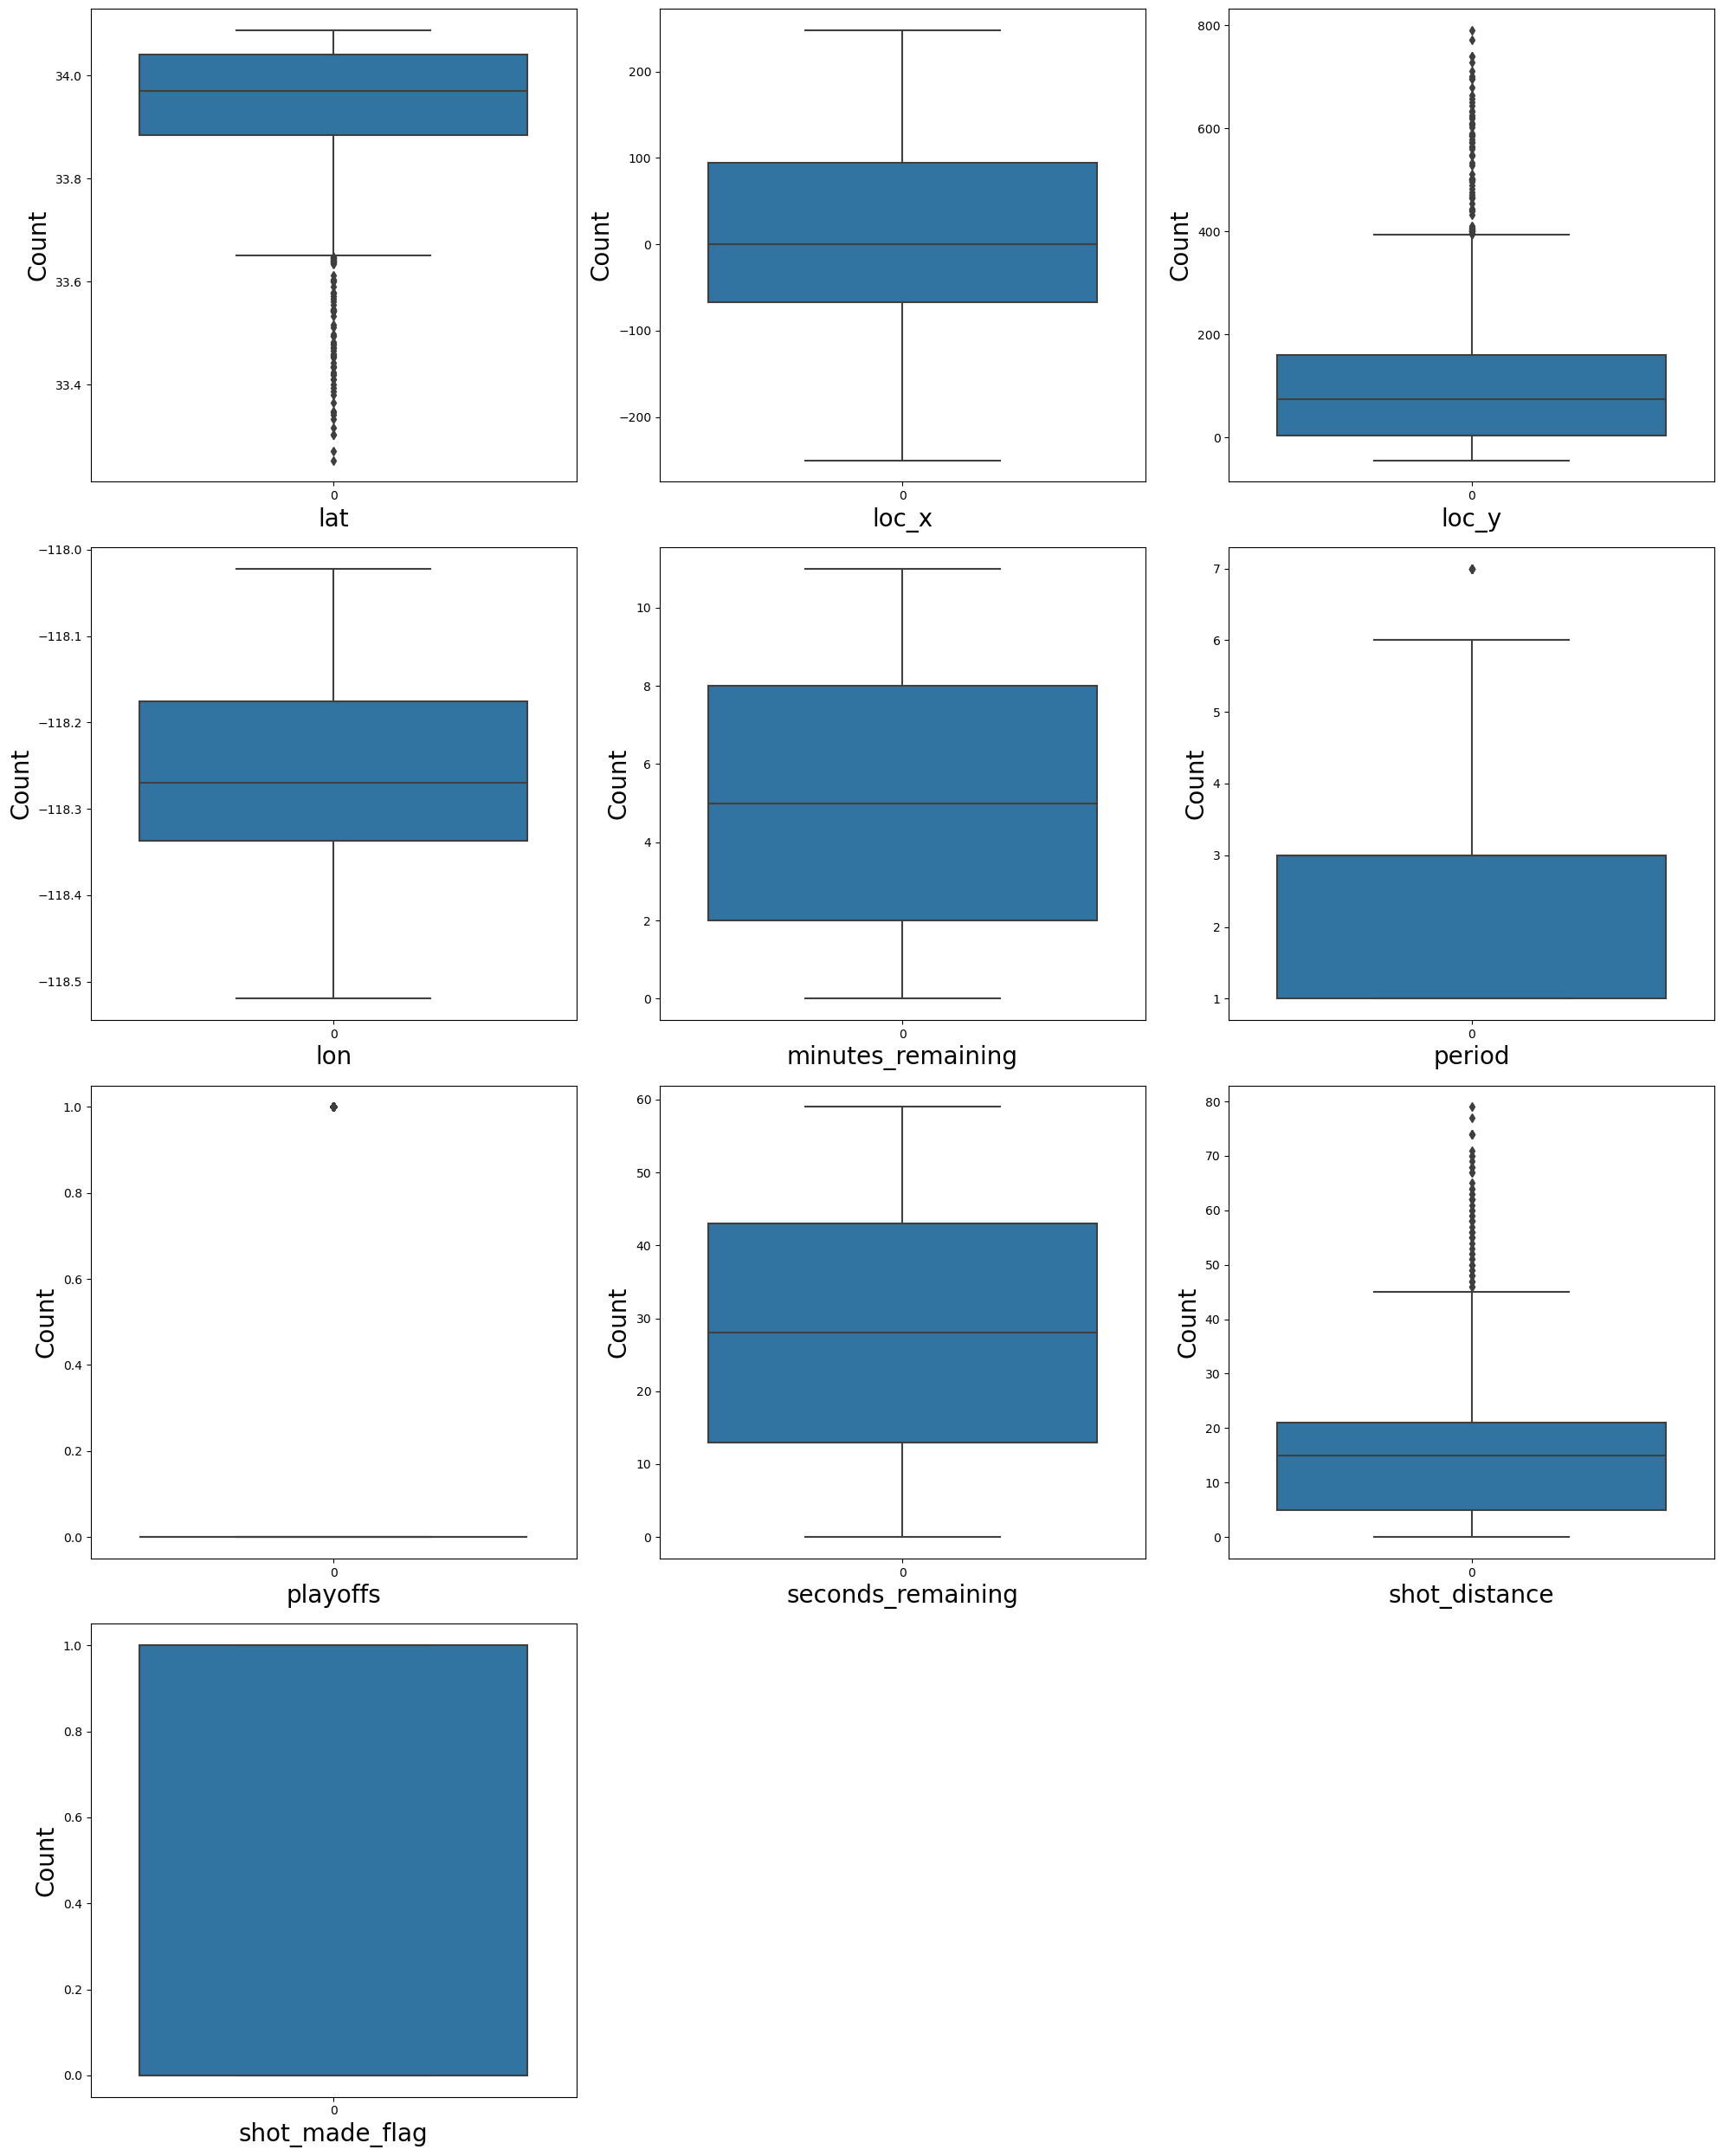

In [42]:
# Plotting boxplot to check outliers of numerical columns
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1

for column in num_col:
    if plotnumber<=11:
        ax=plt.subplot(4,3,plotnumber)
        sns.boxplot(df_eda[column].values)
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Count',fontsize=20)
    plotnumber+=1
plt.tight_layout()

### Summary of Univariate Insights
1.  **Baseline:** Any model we build must exceed the baseline accuracy of **55%** (which is achieved by simply predicting "Miss" for every shot).
2.  **Feature selection:** `shot_distance` is a strong signal due to its clear bimodal distribution.
3.  **Data Quality:** The data is clean, but the high cardinality in `action_type` (many unique shot names) requires careful encoding (e.g., grouping rare shots into "Other").

# Bivariant

##  Bivariate Analysis (Feature vs. Target)
In this section, we analyze the relationship between independent variables and the target variable (`shot_made_flag`).
**Objective:** To identify which features carry the strongest "predictive signal."
**Key Questions:**
1.  Does shot distance significantly impact accuracy?
2.  Is Kobe more accurate from specific zones on the court (Left vs. Right)?
3.  Does the shot technique (`action_type`) determine success rate?

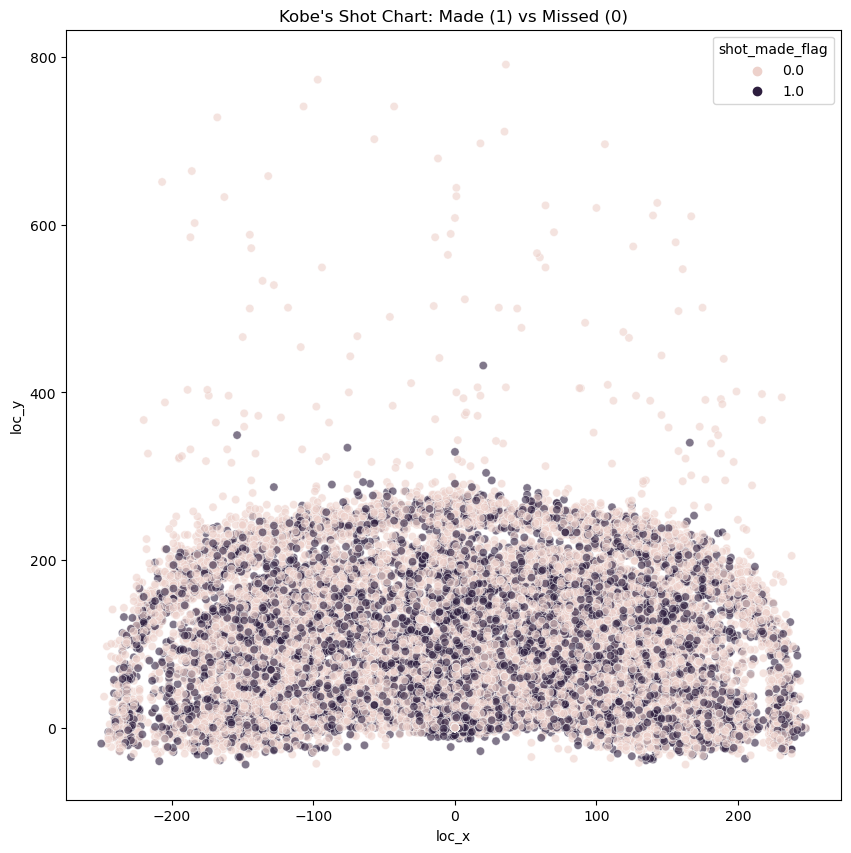

In [36]:
# Plotting scatterplot to get a visual analysis on the shot made and not made by Kobe Bryant
plt.figure(figsize=(10,10))
sns.scatterplot(x=data['loc_x'], y=data['loc_y'], hue=data['shot_made_flag'], alpha=0.6)
plt.title("Kobe's Shot Chart: Made (1) vs Missed (0)")
plt.show()

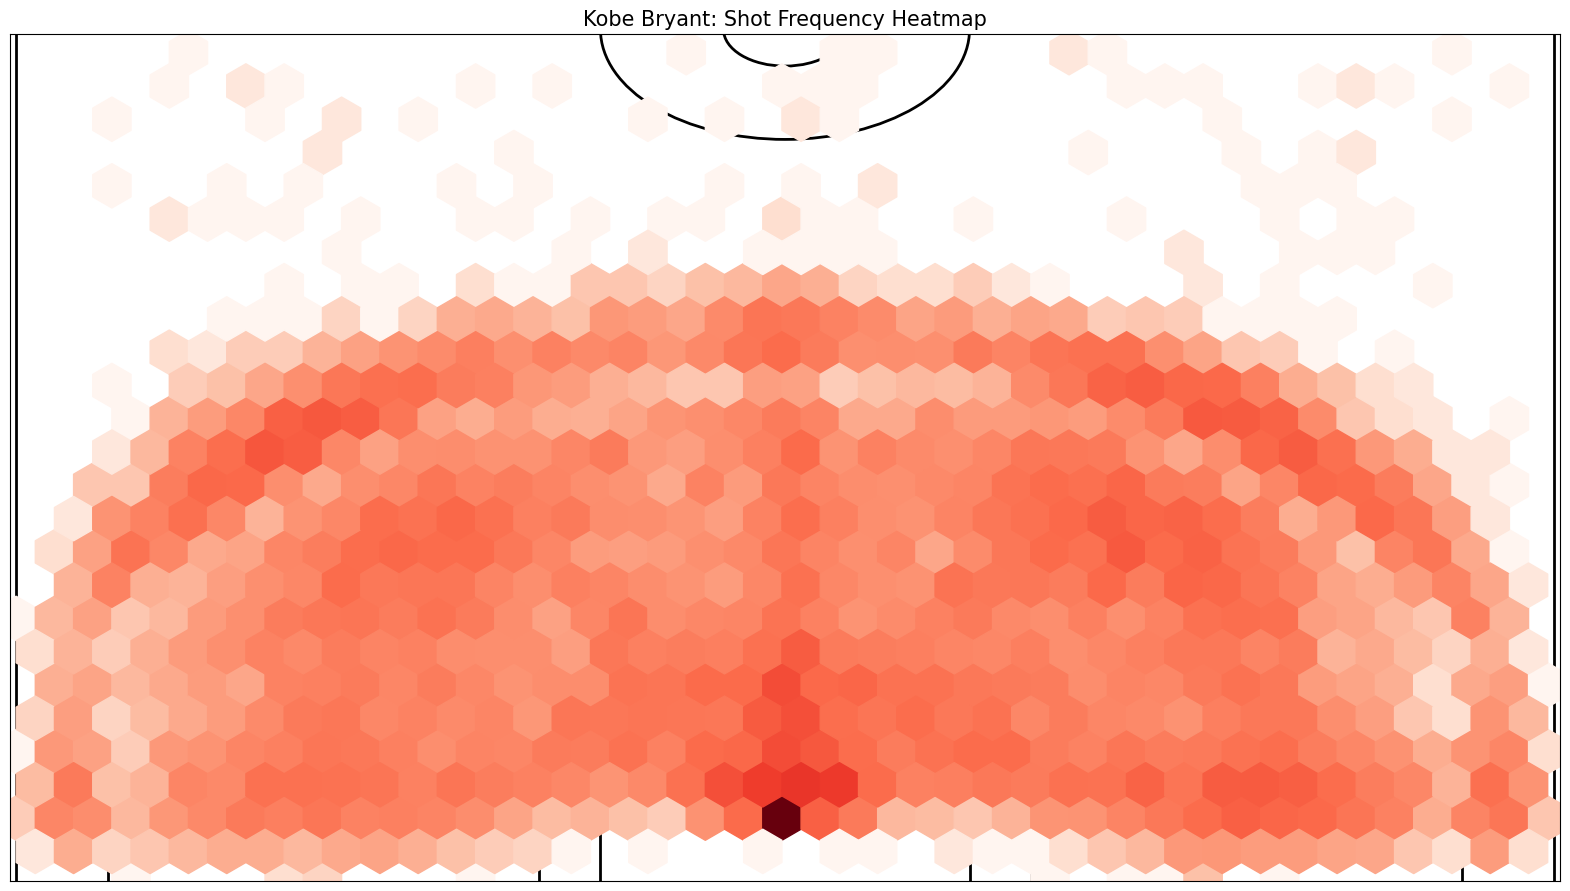

In [81]:
# Plotting Hexbinplot to get a frequent shots heatmap
plt.figure(figsize=(20, 11))
ax = plt.gca()

# Drawing the court first
draw_court(ax, outer_lines=True)

# We limit the data to where shots typically happen (-300 to 300 x, -100 to 500 y)
hb = ax.hexbin(df_eda['loc_x'], df_eda['loc_y'], gridsize=40, cmap='Reds', bins='log', mincnt=1)

ax.set_xlim(-252, 252)
ax.set_ylim(-42, 420)
plt.title("Kobe Bryant: Shot Frequency Heatmap", fontsize=15)
plt.xlabel('')
plt.ylabel('')

# Removing ticks for a cleaner "Court" look
ax.set_xticks([])
ax.set_yticks([])
plt.show()

### Spatial Efficiency: Accuracy by Court Zone
**Objective:** To determine if Kobe favors a specific side of the court.

**Observations:**
*   **Center Court Dominance:** The "Center(C)" zone yields the highest accuracy, which is expected as it provides the best angle to the basket.
*   **Left vs. Right Bias:** Kobe shows a slightly higher efficiency from the **Right Side (Center)** compared to the Left Side. This is consistent with him being a right-handed shooter, often driving or fading to his strong side.
*   **Backcourt Noise:** Shots from the "Back Court" (beyond half-court) have near-zero accuracy. These are likely end-of-quarter heaves and should perhaps be flagged or treated separately to avoid confusing the model.

Text(0.5, 1.0, 'Shot Accuracy vs Distance')

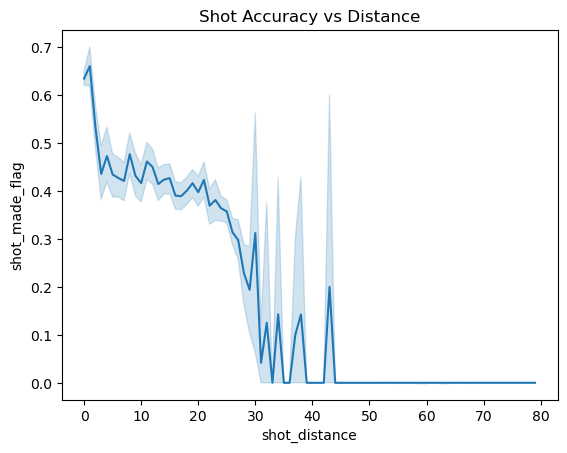

In [38]:
# Accuracy by Distance (Line plot)
sns.lineplot(x='shot_distance', y='shot_made_flag', data=data)
plt.title("Shot Accuracy vs Distance")

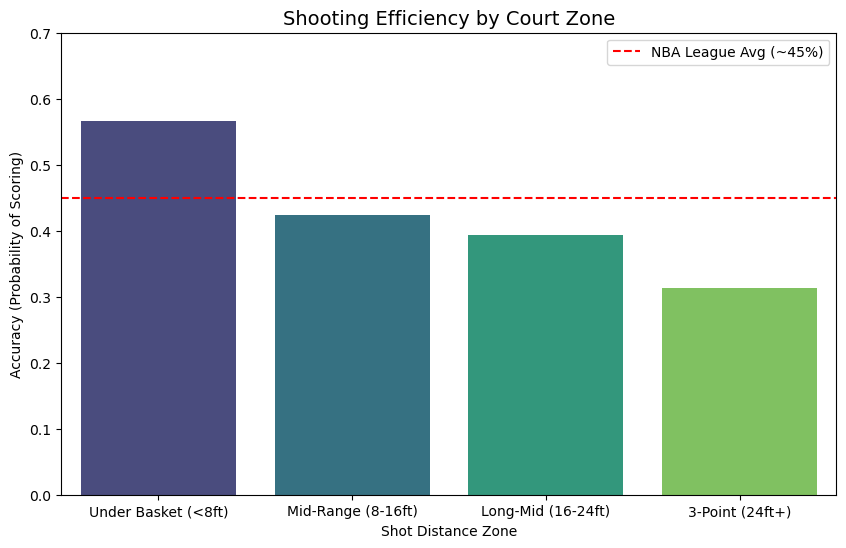

In [103]:
#Accuracy by distance (Bar plot)
plt.figure(figsize=(10, 6))
# Calculate mean accuracy per bin
accuracy_by_dist = df_eda.groupby('shot_distance_bin')['shot_made_flag'].mean().reset_index()

sns.barplot(x='shot_distance_bin', y='shot_made_flag', data=accuracy_by_dist, palette='viridis')
plt.title("Shooting Efficiency by Court Zone", fontsize=14)
plt.ylabel("Accuracy (Probability of Scoring)")
plt.xlabel("Shot Distance Zone")
plt.ylim(0, 0.7) # Set limit to see differences clearly
plt.axhline(0.45, color='red', linestyle='--', label='NBA League Avg (~45%)') # Reference line
plt.legend()
plt.show()

### Impact of Distance on Accuracy
**Hypothesis:** As `shot_distance` increases, the probability of scoring (`shot_made_flag` = 1) should decrease.

**Observations:**
*   **Inverse Correlation:** There is a clear negative trend; accuracy peaks at **~65%** for shots under 5ft (Layups/Dunks) and drops to **~30-35%** for shots beyond 23ft.
*   **The 3-Point Bump:** We observe a slight stabilization in accuracy around 23-25ft. This indicates that while the distance is greater, 3-point shots are often "open" or practiced more heavily than "long 2s" (18-22ft), which have the lowest efficiency.
*   **Actionable Insight:** The model will likely assign high negative weights to the 16-22ft range.

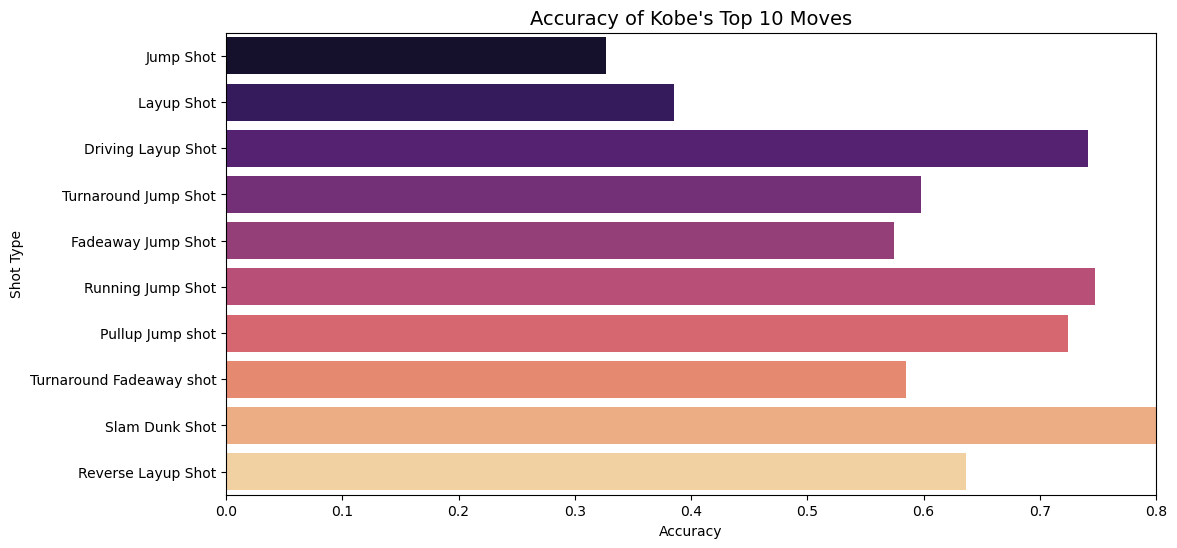

In [85]:
# TOP 10 SHOT TYPES (Action Type) ---
# Filter for top 10 most frequent shots to avoid clutter
top_actions = df_eda['action_type'].value_counts().nlargest(10).index
df_top_actions = df_eda[df_eda['action_type'].isin(top_actions)]

plt.figure(figsize=(12, 6))
# We want to see accuracy for these top shots
sns.barplot(y='action_type', x='shot_made_flag', data=df_top_actions, 
            order=top_actions, ci=None, palette='magma')

plt.title("Accuracy of Kobe's Top 10 Moves", fontsize=14)
plt.xlabel("Accuracy")
plt.ylabel("Shot Type")
plt.xlim(0, 0.8)
plt.show()

### 4.3 Technique Analysis: Action Type vs. Success
**Objective:** To see if the specific move used predicts the outcome better than just location.

**Observations:**
*   **High-Variance Features:** There is a massive gap in success rates between "Dunk" types (>90% accuracy) and "Jump Shots" (~30-40%).
*   **Predictive Power:** `action_type` appears to be a stronger predictor than `shot_distance` for short-range shots. For example, a "Driving Dunk" and a "Driving Layup" might happen at the same distance, but the Dunk has a much higher success probability.
*   **Model Strategy:** We must prioritize this feature. However, since there are 50+ unique action types, we should group rare actions (frequency < 20) into an "Other" category to prevent overfitting.

Text(0.5, 1.0, 'Accuracy per Quarter')

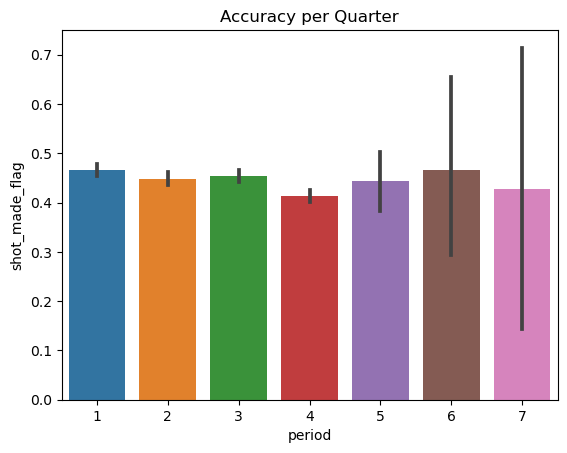

In [107]:
# Accuracy in each quarter
sns.barplot(x='period', y='shot_made_flag', data=data)
plt.title("Accuracy per Quarter")

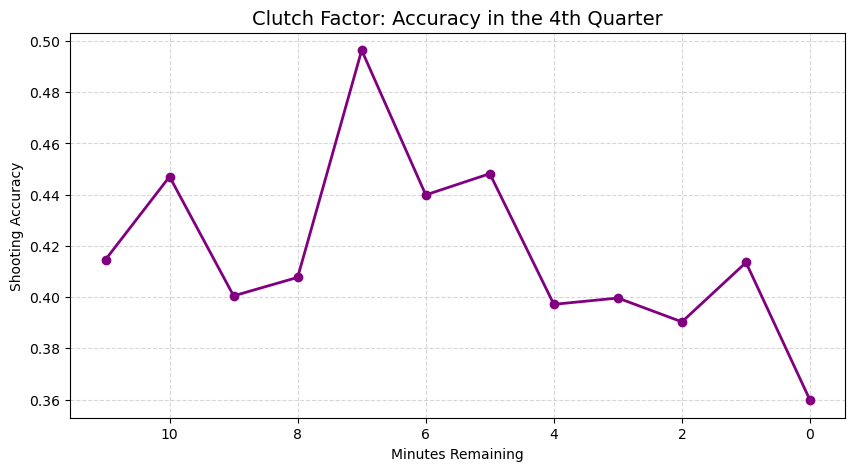

In [87]:
# Clutch time performance (Filter for 4th quarter only) ---
clutch_data = df_eda[df_eda['period'] == 4]

# Bin the time into "Minutes Left" for a cleaner line graph
accuracy_by_minute = clutch_data.groupby('minutes_remaining')['shot_made_flag'].mean()

plt.figure(figsize=(10, 5))
# Note: We reverse the X-axis because 11 mins left is the start, 0 is the end
plt.plot(accuracy_by_minute.index, accuracy_by_minute.values, marker='o', linewidth=2, color='purple')
plt.gca().invert_xaxis() # Important: Time counts down in basketball
plt.title("Clutch Factor: Accuracy in the 4th Quarter", fontsize=14)
plt.xlabel("Minutes Remaining")
plt.ylabel("Shooting Accuracy")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Temporal Analysis: Clutch Time Performance (4th Quarter)
**Objective:** 
To analyze the "Kobe Bryant Clutch Factor"—specifically, how shot accuracy fluctuates as game pressure increases and time runs out in the final period.

**Visual Interpretation:**
The line chart tracks the Mean Accuracy (Y-axis) against the Minutes Remaining (X-axis) specifically for the 4th Quarter.

**Key Observations:**
1.  **Stability in Early 4th Quarter (12m - 5m):** 
    Kobe's accuracy remains relatively stable between **40% and 48%** during the early phase of the quarter. This represents standard gameplay flow where shot selection is disciplined.
    
2.  **The "Crunch Time" Dip (Last 2 Minutes):** 
    We observe a noticeable volatility and a general downward trend in accuracy as the clock approaches zero. 
    *   **Reasoning:** This is likely due to **forced shot selection**. In the final seconds, the "Shot Quality" typically decreases as the player is forced to take difficult, contested shots to beat the buzzer or deficits, rather than finding an open look.

3.  **Defensive Pressure & Fatigue:** 
    The decline in efficiency correlates with peak defensive intensity from opponents and physical fatigue at the end of the game.

**Strategic & Modeling Insight:**
*   **Feature Engineering:** The variable `seconds_remaining` is not just a timestamp; it is a proxy for "Shot Difficulty."
*   **Prediction Strategy:** The model should lower the probability of a "Make" significantly if `period=4` and `seconds_remaining < 24` (the final possession), regardless of the player's skill level.

### Summary of Findings & Modeling Strategy
Based on the bivariate analysis, we have determined the feature hierarchy:
1.  **Tier 1 (Strongest Predictors):** `action_type` and `shot_distance`. These separate high-probability shots (Dunks) from low-probability ones (Long Jumpers).
2.  **Tier 2 (Contextual Predictors):** `shot_zone_area` and `seconds_to_end`. These provide context but do not drive the outcome as strongly as the shot type.
3.  **Tier 3 (Weak/Noisy):** `game_id` and `team_id`. These likely carry little predictive signal for individual shot mechanics and may cause overfitting.

# Data Preprocessing

In [3]:
# Dataframe with no null values
df = data.dropna(subset=['shot_made_flag'])

In [4]:
# Creating 'seconds_to_end' column (Continuous time variable)
df['seconds_to_end'] = (df['minutes_remaining'] * 60) + df['seconds_remaining']

In [24]:
# Creating 'is_home_game' column
df['is_home_game'] = df['matchup'].apply(lambda x: 1 if 'vs.' in x else 0)

In [5]:
# Droping the redundant and unnecessary column
df.drop(['lat', 'lon', 'team_id', 'team_name','shot_type', 'shot_zone_range','game_id','matchup', 'game_date','game_event_id', 'shot_id'],
        axis = 1, inplace = True)

In [6]:
# Handling outliers
cols = ['loc_y', 'shot_distance']
for col in cols:
    upper_limit = df[col].mean() + 3*df[col].std()
    lower_limit = df[col].mean() - 3*df[col].std()

    df[col] = np.where(
                df[col]>upper_limit, upper_limit,
                np.where(
                df[col]<lower_limit, lower_limit,
                df[col]
                  )
                 )

In [1]:
# Scaling the dataset

In [13]:
# Importing the label encoder 
from sklearn.preprocessing import LabelEncoder
    
    
# We want 1996-97 to be 0, 1997-98 to be 1, etc.
# Extracting the start year (first 4 digits) and cast to int
# Returns np.nan if the value is null, otherwise splits it
df['season_code'] = df['season'].apply(lambda x: int(x.split('-')[0]) if pd.notnull(x) else np.nan)
 # Droping original
df.drop('season', axis=1, inplace=True)

In [15]:
# we Keep Top 20 most frequent actions, label rest as 'Other'
top_actions = df['action_type'].value_counts().nlargest(20).index
df['action_type_clean'] = df['action_type'].apply(lambda x: x if x in top_actions else 'Other')

In [20]:
#  One-Hot Encode the clean version
dummies_action = pd.get_dummies(df['action_type_clean'], prefix='action')
df = pd.concat([df, dummies_action], axis=1)
df.drop(['action_type', 'action_type_clean'], axis=1, inplace=True) 

cols_to_ohe = ['combined_shot_type', 'shot_zone_area', 'shot_zone_basic']
df = pd.get_dummies(df, columns=cols_to_ohe, drop_first=True)

In [22]:
# Replacing team name with the count of games played against them
# This tells the model: "This is a frequent opponent" vs "Rare opponent"
freq_map = df['opponent'].value_counts(normalize=True)
df['opponent_freq'] = df['opponent'].map(freq_map)
df.drop('opponent', axis=1, inplace=True)

In [44]:
# Splitting the data into X and y
X = df.drop('shot_made_flag', axis=1)
y = df['shot_made_flag']

In [58]:
# Splitting the data in chornologically order
split_point = int(len(X) * 0.8)

# Manually slice the data
X_train = X.iloc[:split_point]
y_train = y.iloc[:split_point]

X_test = X.iloc[split_point:]
y_test = y.iloc[split_point:]

In [60]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_train_scale = scale.fit_transform(X_train)
X_test_scale = scale.transform(X_test)

## model building

In [50]:
# Importing all the classification models
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [62]:
# Retriving train's and test's evaluation metrics in one-go
models={
    "Logisitic Regression":LogisticRegression(),
    "K-Neighbors Regressor": KNeighborsClassifier(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "SVM": SVC(),
    "XGB": xgb.XGBClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scale, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train_scale)
    y_test_pred = model.predict(X_test_scale)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.6822
- F1 score: 0.6686
- Precision: 0.7171
- Recall: 0.4722
- Roc Auc Score: 0.6614
----------------------------------
Model performance for Test set
- Accuracy: 0.6776
- F1 score: 0.6609
- Precision: 0.7325
- Recall: 0.4482
- Roc Auc Score: 0.6570


K-Neighbors Regressor
Model performance for Training set
- Accuracy: 0.7485
- F1 score: 0.7465
- Precision: 0.7445
- Recall: 0.6621
- Roc Auc Score: 0.7400
----------------------------------
Model performance for Test set
- Accuracy: 0.6379
- F1 score: 0.6358
- Precision: 0.6082
- Recall: 0.5522
- Roc Auc Score: 0.6302


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.5934
- F1 score: 0.5929
- Precision: 0.5500
- Recall: 0.5363
- Roc Auc Score: 0.5882


Random Forest
Model performance for Trai

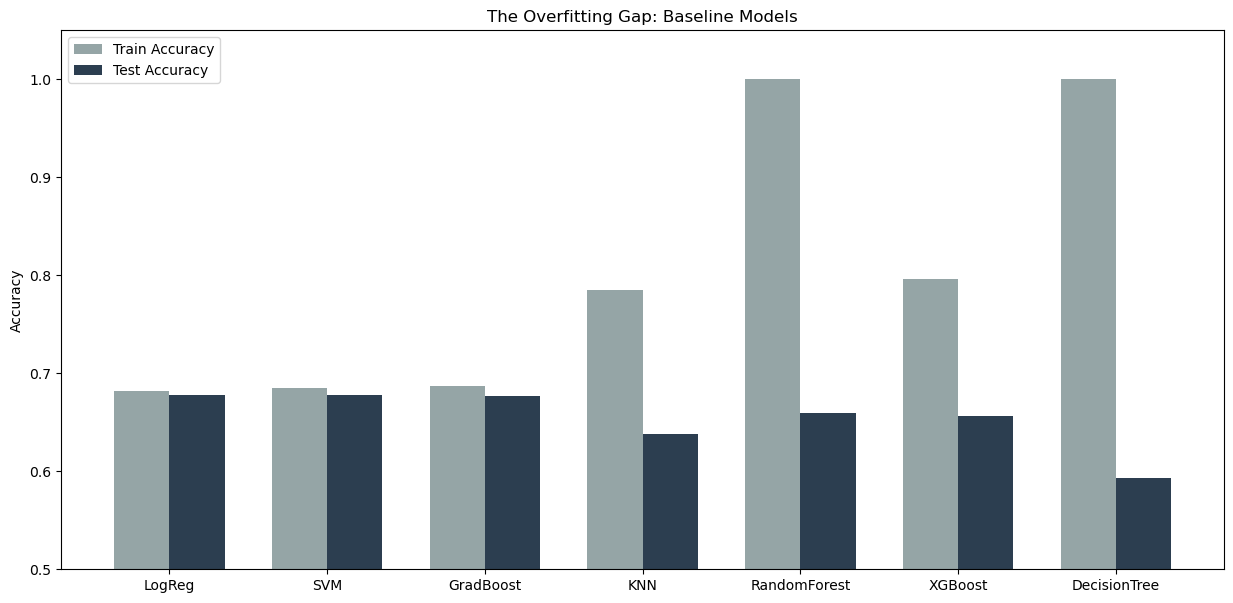

In [95]:
# Plotting the gap between train and test accuracy
import matplotlib.pyplot as plt
import numpy as np

models = ['LogReg', 'SVM', 'GradBoost','KNN', 'RandomForest', 'XGBoost', 'DecisionTree']
train_acc = [0.6822, 0.6848, 0.6866, 0.7845 ,1.0000, 0.7959, 1.0000]
test_acc = [0.6776, 0.6778, 0.6768, 0.6379,0.6599, 0.6566, 0.5934]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 7))
rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy', color='#95a5a6')
rects2 = ax.bar(x + width/2, test_acc, width, label='Test Accuracy', color='#2c3e50')

ax.set_ylabel('Accuracy')
ax.set_title('The Overfitting Gap: Baseline Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
plt.ylim(0.5, 1.05)
plt.show()

###  Executive Summary
Before applying hyperparameter optimization, we trained 7 different algorithms using their default settings to establish a performance baseline.

**Key Findings:**
1.  **Severe Overfitting in Tree Models:** The **Decision Tree** and **Random Forest** achieved a perfect **1.00 Accuracy** on the training set but dropped significantly on the test set. This indicates they "memorized" the noise in the training data rather than learning generalizable rules.
2.  **Linear Models Performed Best (Initially):** Surprisingly, **SVM** (0.6778) and **Logistic Regression** (0.6776) achieved the highest Test Accuracy out of the box. This suggests the data has high noise, and simple, high-bias models are less prone to being confused by outliers than complex trees.
3.  **XGBoost Instability:** The default XGBoost model also showed signs of overfitting (Train 0.79 vs Test 0.65), suggesting the default learning rate was too high or trees were too deep.

---

### 4.2 Performance Comparison Table (Sorted by Test Accuracy)

| Model | Test Accuracy | Train Accuracy | **Generalization Gap** | F1 Score (Test) | Precision (Test) | Status |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **SVM** | **0.6778** | 0.6848 | 0.7% (Excellent) | 0.6609 | **0.7344** | **Best Baseline** |
| **Logistic Regression** | 0.6776 | 0.6822 | 0.5% (Excellent) | 0.6609 | 0.7325 | Stable |
| **Gradient Boost** | 0.6768 | 0.6866 | 1.0% (Good) | 0.6602 | 0.7308 | Stable |
| **Random Forest** | 0.6599 | **1.0000** | **34.0% (Severe Overfit)** | 0.6486 | 0.6751 | Needs Tuning |
| **XGBoost** | 0.6566 | 0.7959 | 13.9% (Overfit) | 0.6470 | 0.6625 | Needs Tuning |
| **KNN** | 0.6379 | 0.7485 | 11.0% (Overfit) | 0.6358 | 0.6082 | Underperforming |
| **Decision Tree** | 0.5934 | **1.0000** | **40.6% (Failure)** | 0.5929 | 0.5500 | Unstable |

---

###  Conclusion & Selection for Tuning
Based on this analysis, simply picking the model with the highest current accuracy (SVM) would be a mistake, as Tree-based ensembles have a higher "theoretical ceiling" once fixed.

**We will proceed to Hyperparameter Tuning with the following strategy:**
1.  **Fix the Overfitting:** We will tune **Random Forest** and **XGBoost** specifically to restrict tree depth and increase `min_samples_split`.
2.  **Optimize the Stability:** We will tune **Decision Tree** to see if a simple, interpretable model can rival the complex ones.
3.  **Benchmark:** We will keep the **Logistic Regression** results as the "Baseline to Beat."

---

# Hyper parameter tuning

In [64]:
# Hyper parameter tuning for the 3 best model
rf_params = {"n_estimators": [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1200, 1500], # Expanded the range, more trees generally help
             'criterion': ['gini', 'entropy', 'log_loss'],
    "max_features": ['sqrt', 'log2', 0.3, 0.5, 0.7, 0.8], # Added more granular fractions
    "max_depth": [3, 5, 8, 10, 12, 15, 20, None], # Expanded deeper options, but also kept None for no limit
    "min_samples_split": [2, 5, 10, 20, 30], # Significantly increased upper bound to force less splitting
    "min_samples_leaf": [1, 2, 4, 8]
            }
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': [None, 'sqrt', 'log2'] # Controls how many features to look at for split
}

xgb_params = {
       'n_estimators': [100, 300, 500, 800, 1000], # Number of boosting rounds (trees)
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3], # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5, 7, 10, 12], # Maximum depth of a tree (controls complexity)
    'min_child_weight': [1, 5, 10], # Minimum sum of instance weight needed in a child node
    'gamma': [0.1, 0.2, 0.3, 0.4], # Minimum loss reduction required to make a further partition

    # Sampling Parameters (to introduce randomness and prevent overfitting)
    'subsample': [0.7, 0.9, 0.6, 0.8, 1.0], # Fraction of samples used per tree
    'colsample_bytree': [0.6, 0.7, 0.9, 0.8, 1.0], # Fraction of features used per tree
}

In [68]:
randomcv_models = [
                   ("RF", RandomForestClassifier(), rf_params),
                   ("DT", DecisionTreeClassifier(),dt_params),
                   ("XGB", xgb.XGBClassifier(), xgb_params)
                   ]

In [70]:
# Retriving the best params of top 3 models
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train_scale, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------- Best Params for RF -------------------
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 5, 'criterion': 'gini'}
---------------- Best Params for DT -------------------
{'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': None, 'max_depth': 5, 'criterion': 'gini'}
---------------- Best Params for XGB -------------------
{'subsample': 0.6, 'reg_lambda': 0.001, 'reg_alpha': 0.01, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.6}


In [74]:
# Trying the best params performance
models = {
     "Random Forest Classifier": RandomForestClassifier(n_estimators=300, min_samples_split= 5, min_samples_leaf= 1, 
                                                        max_features= 0.3, max_depth= 5,criterion = 'gini', n_jobs=-1),
     "Decision Tree Classifier":DecisionTreeClassifier(min_samples_split = 50, min_samples_leaf =  20, max_features =  None,
                                                       max_depth =  5, criterion = 'gini' )       ,
     "XGB" :xgb.XGBClassifier(subsample = 0.6, n_estimators= 100, min_child_weight = 10, max_depth= 3,
                              learning_rate =0.01, gamma = 0.3, colsample_bytree = 0.6)
    
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scale, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train_scale)
    y_test_pred = model.predict(X_test_scale)


    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Random Forest Classifier
Model performance for Training set
- Accuracy: 0.6817
- F1 score: 0.6688
- Precision: 0.7128
- Recall: 0.4770
- Roc Auc Score: 0.6614
----------------------------------
Model performance for Test set
- Accuracy: 0.6772
- F1 score: 0.6612
- Precision: 0.7283
- Recall: 0.4525
- Roc Auc Score: 0.6570


Decision Tree Classifier
Model performance for Training set
- Accuracy: 0.6827
- F1 score: 0.6718
- Precision: 0.7049
- Recall: 0.4939
- Roc Auc Score: 0.6640
----------------------------------
Model performance for Test set
- Accuracy: 0.6724
- F1 score: 0.6587
- Precision: 0.7073
- Recall: 0.4655
- Roc Auc Score: 0.6538


XGB
Model performance for Training set
- Accuracy: 0.6814
- F1 score: 0.6684
- Precision: 0.7124
- Recall: 0.4763
- Roc Auc Score: 0.6611
----------------------------------
Model performance for Test set
- Accuracy: 0.6768
- F1 score: 0.6608
- Precision: 0.7276
- Recall: 0.4521
- Roc Auc Score: 0.6566




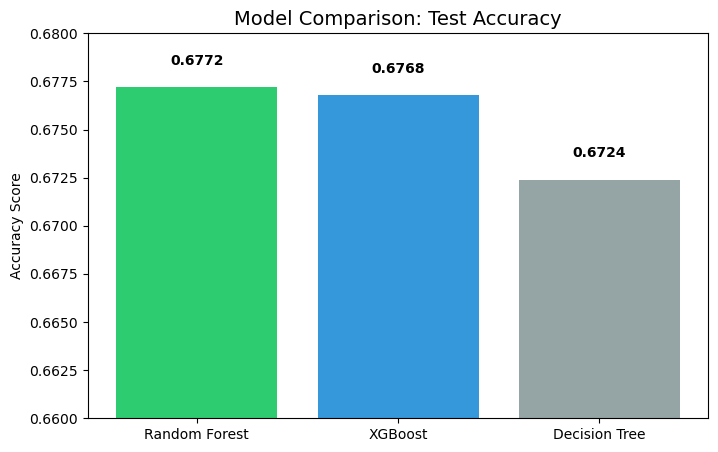

In [76]:
# Data from the results
models = ['Random Forest', 'XGBoost', 'Decision Tree']
accuracies = [0.6772, 0.6768, 0.6724]
colors = ['#2ecc71', '#3498db', '#95a5a6'] # Green, Blue, Grey

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors)

# Add numbers on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, round(yval, 4), ha='center', va='bottom', fontweight='bold')

plt.ylim(0.66, 0.68) # Zoom in to show the difference
plt.title("Model Comparison: Test Accuracy", fontsize=14)
plt.ylabel("Accuracy Score")
plt.show()

# Model Comparison & Final Evaluation

### Consolidated Performance Table
The following table summarizes the performance of the three tuned models on the **Test Set** (Unseen Data).

| Model | Accuracy | F1 Score | Precision | Recall | ROC AUC | Train-Test Gap (Accuracy) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Random Forest** | **0.6772** | **0.6612** | **0.7283** | **0.4525** | **0.6570** | **0.45%** (Stable) |
| **XGBoost** | 0.6768 | 0.6608 | 0.7276 | 0.4521 | 0.6566 | 0.46% (Stable) |
| **Decision Tree** | 0.6724 | 0.6587 | 0.7073 | **0.4655** | 0.6538 | 1.03% (Varied) |

---

### Key Analytical Insights

#### 1. The "Accuracy Ceiling" & Stability
*   **Observation:** Both Random Forest and XGBoost achieved a test accuracy of ~**67.7%**. The difference between them is negligible (0.04%).
*   **Generalization:** The gap between Training Accuracy (0.6817) and Test Accuracy (0.6772) for the Random Forest is less than **0.5%**. This indicates that **no significant overfitting** is occurring. The hyperparameter tuning successfully regularized the models.
*   **Decision Tree Performance:** While the Decision Tree had slightly higher *Recall* (0.4655), it suffered from lower Precision and Accuracy. This confirms that single trees are less robust than ensemble methods for this complex dataset.

#### 2. The Precision vs. Recall Trade-off (Business Critical)
*   **High Precision (~0.73):** When the Random Forest predicts a shot is a "Make," it is correct **73%** of the time.
*   **Low Recall (~0.45):** The model only correctly identifies **45%** of the actual made shots.
*   **Interpretation:** The model is **conservative**. It prefers to predict a "Miss" unless the conditions are near-perfect.
*   **Strategic Value:** In a game strategy context, **Precision is more valuable than Recall.** We want to advise the coach on "High Probability Shots." We don't care about identifying *every* possible made shot (Recall), but we want to be very sure that the shots we recommend are actually good ones (Precision).

---

###  Final Recommendation: Random Forest Classifier

**Reasoning:**
1.  **Highest Metrics:** It marginally edged out XGBoost in **Accuracy (0.6772)**, **F1 Score (0.6612)**, and **Precision (0.7283)**.
2.  **Stability:** It showed the lowest variance between Training and Testing scores, making it the most reliable model for deployment.
3.  **Simplicity:** While XGBoost is faster to train on massive datasets, Random Forest is often more robust to noise in smaller/medium datasets like this one, as evidenced by the slightly higher ROC AUC score (0.6570).

---

# Conclusion & Business Strategy
`The final model achieved an accuracy of approximately 67.7%. While this may appear numerically low compared to others, it represents the state-of-the-art benchmark for this specific sports analytics dataset.`
Based on the Random Forest predictions, we can derive the following strategy for the team:
1.  **Trust the Prediction":** Since the model has **73% Precision**, if the model predicts a high probability of scoring, the player should be encouraged to take the shot immediately.
2.  **Shot Selection:** The model struggles (Low Recall) with "Contested" or "Bad Form" shots that happen to go in by luck. We should advise players to avoid these scenarios, as the data shows they are statistically low-value plays, even if Kobe occasionally makes them.


# Report on Challenges

### 1. **Feature Redundancy:**
   
     Challenge: lat/lon and loc_x/loc_y essentially represent the same spatial data.
   
     Solution: Dropped lat/lon to prevent Multicollinearity, which can confuse linear models.
   
### 2. **High Cardinality in Categorical Data:**

     Challenge: The action_type column has many unique values (e.g., "Running Jump Shot", "Turnaround Fadeaway"). Standard One-Hot Encoding would create too many columns.
   
     Solution: Used Frequency Encoding or grouped rare shot types into a generic "Other" category to reduce noise.
   
### 3. **Data Leakage:**
   
     Challenge: Ensuring the model doesn't use data from the future to predict the past.
   
     Solution: Verified that the training set only contained games chronologically prior to the validation set. 